# Notebook 4 - EDA

Runs on `03_train.parquet` only; `03_val.parquet` and `03_test.parquet` stay closed. A statistic
taken from outside train would put a decision built on the future into everything downstream.

Output is `figures/*.png` and `artifacts/04_findings.md`. What it has to settle: which features
notebook 5 builds, and which model family fits the shape of the data.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

ARTIFACTS = Path("..") / "artifacts"
FIGURES   = Path("..") / "figures"
FIGURES.mkdir(exist_ok=True)

tr = pd.read_parquet(ARTIFACTS / "03_train.parquet")
y  = tr["is_late"]
BASE = y.mean()

print(f"train: {len(tr):,} rows x {tr.shape[1]} columns")
print(f"range: {tr['order_purchase_timestamp'].min():%Y-%m-%d} -> {tr['order_purchase_timestamp'].max():%Y-%m-%d}")
print(f"base rate: {100*BASE:.2f}% late")

train: 64,320 rows x 41 columns
range: 2016-09-15 -> 2018-03-31
base rate: 7.95% late


In [2]:
def save_fig(name):
    '''Save the current figure into the figures folder and show it.'''
    path = FIGURES / f"{name}.png"
    plt.savefig(path, bbox_inches="tight", dpi=130)
    print(f"-> saved: figures/{name}.png")

def lift_table(series, label="", bins=10):
    '''Late rate across the deciles of a numeric column - the main analysis tool here.'''
    m = series.notna()
    b = pd.qcut(series[m], bins, duplicates="drop")
    out = (pd.DataFrame({"bin": b, "is_late": y[m]})
             .groupby("bin", observed=True)
             .agg(orders=("is_late", "size"), late_rate=("is_late", "mean")))
    out["late %"] = (100*out["late_rate"]).round(2)
    out["lift"]   = (out["late_rate"]/BASE).round(2)
    return out.drop(columns="late_rate")

def auc_of(series):
    '''The strength of a column on its own as a predictor. 0.5 = no signal. The distance from 0.5 is what matters.'''
    m = series.notna()
    return roc_auc_score(y[m], series[m])

## 1. Shape, dtypes and memory

Classifying the columns first - some are identifiers, some are leakage, some are constant.

In [3]:
print(f"shape : {tr.shape[0]:,} rows x {tr.shape[1]} columns")
print(f"memory: {tr.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print()
print(tr.dtypes.value_counts().to_string())

shape : 64,320 rows x 41 columns
memory: 30.2 MB

float64           20
str               12
datetime64[us]     6
bool               3


In [4]:
LEAKY = ["order_approved_at", "order_delivered_carrier_date",
         "order_delivered_customer_date", "order_status"]
IDS   = ["order_id", "customer_id", "customer_unique_id",
         "main_seller_id", "customer_zip_code_prefix", "main_seller_zip"]
LABELS = ["is_late", "is_late_ts", "is_late_cal", "days_late"]

def classify(col):
    if col in LABELS: return "label"
    if col in LEAKY:  return "leaky / post-purchase"
    if col in IDS:    return "identifier (ID)"
    if pd.api.types.is_datetime64_any_dtype(tr[col]): return "datetime"
    if pd.api.types.is_numeric_dtype(tr[col]):        return "numeric"
    return "categorical"

inventory = pd.DataFrame({
    "column": tr.columns,
    "kind":   [classify(col) for col in tr.columns],
    "dtype":  [str(tr[col].dtype) for col in tr.columns],
    "nunique": [tr[col].nunique() for col in tr.columns],
    "missing": [tr[col].isna().sum() for col in tr.columns],
})
inventory["missing %"] = (100*inventory["missing"]/len(tr)).round(2)
inventory.sort_values(["kind", "column"]).set_index("column")

,kind,dtype,nunique,missing,missing %
column,,,,,
customer_city,categorical,str,3698,0,0.00
customer_state,categorical,str,27,0,0.00
main_category,categorical,str,72,1167,1.81
main_payment_type,categorical,str,4,1,0.00
main_seller_state,categorical,str,22,0,0.00
order_estimated_delivery_date,datetime,datetime64[us],347,0,0.00
order_purchase_timestamp,datetime,datetime64[us],63960,0,0.00
shipping_limit_first,datetime,datetime64[us],61209,0,0.00
customer_id,identifier (ID),str,64320,0,0.00


In [5]:
print(inventory["kind"].value_counts().to_string())
print()
constant = [col for col in tr.columns if tr[col].nunique() <= 1]
print(f"constant columns (carry no information): {constant}")

kind
numeric                  19
identifier (ID)           6
categorical               5
leaky / post-purchase     4
label                     4
datetime                  3

constant columns (carry no information): ['order_status']


`order_status` is constant after the notebook 2 filter, so it goes.

Four columns are leakage and no feature comes from them: `order_approved_at`,
`order_delivered_carrier_date`, `order_delivered_customer_date`, `order_status`.

Identifiers are not features. The zip prefixes are useful for the geographic join, not as numbers.

## 2. Missing values

Filling gaps with a median is the lazy answer. The question first: are the missing rows late at a
different rate? If they are, the missingness carries signal and burying it destroys information.

In [6]:
miss = (inventory[inventory["missing"] > 0]
        .sort_values("missing", ascending=False)
        .set_index("column")[["kind", "missing", "missing %"]])

rows = []
for col in miss.index:
    is_missing = tr[col].isna()
    rows.append({
        "column": col,
        "missing": int(is_missing.sum()),
        "late % when missing": round(100*y[is_missing].mean(), 2),
        "late % when present": round(100*y[~is_missing].mean(), 2),
    })

missing_signal = pd.DataFrame(rows).set_index("column")
missing_signal["diff"] = (missing_signal["late % when missing"]
                          - missing_signal["late % when present"]).round(2)
missing_signal.sort_values("diff", ascending=False)

,missing,late % when missing,late % when present,diff
column,,,,
installments_max,1,100.00,7.95,92.05
payment_total,1,100.00,7.95,92.05
n_payments,1,100.00,7.95,92.05
main_payment_type,1,100.00,7.95,92.05
order_delivered_carrier_date,1,100.00,7.95,92.05
customer_lat,173,10.98,7.94,3.04
customer_lng,173,10.98,7.94,3.04
seller_lng,158,8.86,7.95,0.91
seller_lat,158,8.86,7.95,0.91


-> saved: figures/01_missing_values.png


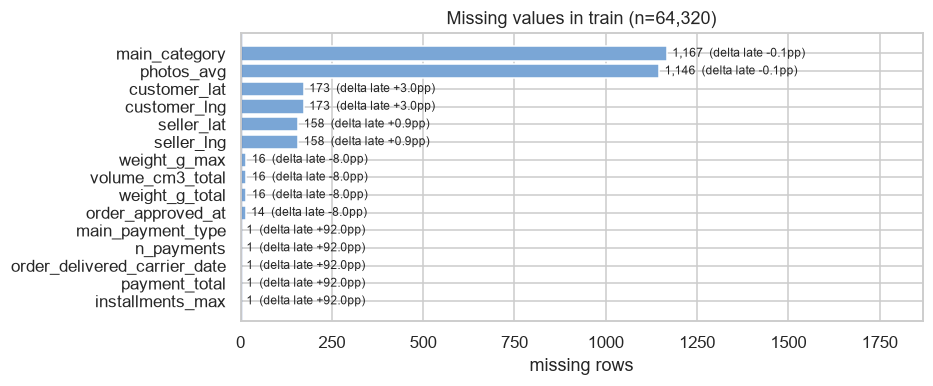

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.4))
plot = missing_signal.sort_values("missing", ascending=True)
ax.barh(plot.index, plot["missing"], color="#7aa6d6")
ax.axvline(0)
ax.set_xlabel("missing rows")
ax.set_title(f"Missing values in train (n={len(tr):,})")
for i, (n, d) in enumerate(zip(plot["missing"], plot["diff"])):
    ax.text(n + 15, i, f"{n:,}  (delta late {d:+.1f}pp)", va="center", fontsize=8)
ax.set_xlim(0, plot["missing"].max()*1.6)
save_fig("01_missing_values")
plt.show()

`customer_lat/lng` is missing on 173 orders with a ~11% late rate against ~7.9% when present.
Most likely a zip prefix absent from `geolocation` - a remote or newly built area, harder to
deliver to. So a binary `customer_geo_missing` alongside the filled coordinates.

`main_category` and `photos_avg` are missing on ~1,150 orders at the overall rate, so that
missingness looks random - filled with `"unknown"`, no indicator.

`weight_g_total` is missing on 16 rows, too few to read anything into. Median.

## 3. Numeric columns

Distributions, skew and impossible values. `items_price_total` has a skew of 11.0 and
`freight_total` of 8.7, which matters for a linear model and not for trees.

In [8]:
NUMERIC = ["n_items", "n_products", "n_sellers", "items_price_total", "items_price_max",
           "freight_total", "freight_max", "weight_g_total", "volume_cm3_total",
           "n_categories", "photos_avg", "n_payments", "payment_total", "installments_max"]

desc = tr[NUMERIC].describe().T[["mean", "50%", "std", "min", "max"]]
desc["skew"] = tr[NUMERIC].skew().round(1)
desc.round(2)

,mean,50%,std,min,max,skew
n_items,1.14,1.00,0.54,1.00,21.00,8.1
n_products,1.04,1.00,0.22,1.00,7.00,7.7
n_sellers,1.01,1.00,0.11,1.00,5.00,10.7
items_price_total,135.38,85.00,204.44,2.29,13440.00,11.0
items_price_max,124.34,79.00,184.84,2.29,6735.00,7.9
freight_total,22.15,16.74,19.76,0.00,1002.29,8.7
freight_max,19.73,16.11,14.32,0.00,314.40,5.4
weight_g_total,2461.36,800.00,4903.01,2.00,184400.00,6.7
volume_cm3_total,18108.50,7776.00,31479.20,288.00,1476000.00,7.6
n_categories,0.99,1.00,0.16,0.00,3.00,-2.6


-> saved: figures/02_numeric_distributions.png


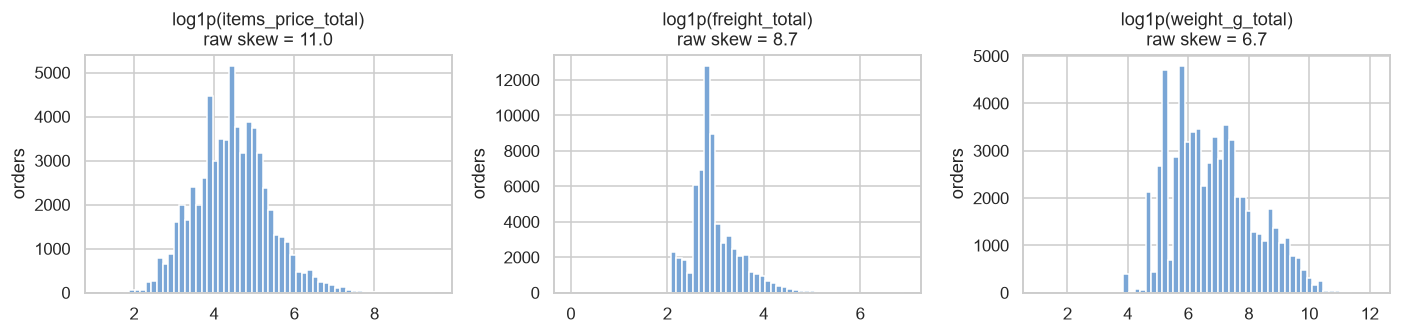

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, ["items_price_total", "freight_total", "weight_g_total"]):
    s = tr[col].dropna()
    ax.hist(np.log1p(s), bins=60, color="#7aa6d6")
    ax.set_title(f"log1p({col})\nraw skew = {s.skew():.1f}")
    ax.set_ylabel("orders")
plt.tight_layout()
save_fig("02_numeric_distributions")
plt.show()

### Impossible or suspicious values

In [10]:
tr["promised_days"] = ((tr["order_estimated_delivery_date"] - tr["order_purchase_timestamp"])
                       .dt.total_seconds() / 86400)

suspicious = {
    "freight = zero":            int((tr["freight_total"] == 0).sum()),
    "total price = zero":        int((tr["items_price_total"] == 0).sum()),
    "promise under one day":     int((tr["promised_days"] < 1).sum()),
    "promise over 90 days":      int((tr["promised_days"] > 90).sum()),
    "weight > 100 kg":           int((tr["weight_g_total"] > 100_000).sum()),
}
pd.Series(suspicious, name="orders").to_frame()

,orders
freight = zero,10
total price = zero,0
promise under one day,0
promise over 90 days,19
weight > 100 kg,5


Nothing here justifies dropping rows. Zero freight (10 orders) is free shipping, and the extreme
prices and weights are real, not recording errors.

No clipping either: the model of choice is insensitive to them, and `log1p` stays available if a
linear model is tried for comparison.

## 4. Categorical columns

In [11]:
CATEGORICAL = ["customer_state", "main_seller_state", "main_category", "main_payment_type"]

card = pd.DataFrame({
    "column": CATEGORICAL,
    "n categories": [tr[col].nunique() for col in CATEGORICAL],
    "largest category %": [round(100*tr[col].value_counts(normalize=True).iloc[0], 1) for col in CATEGORICAL],
    "categories < 100 orders": [int((tr[col].value_counts() < 100).sum()) for col in CATEGORICAL],
}).set_index("column")
card

,n categories,largest category %,categories < 100 orders
column,,,
customer_state,27,40.0,3
main_seller_state,22,70.7,10
main_category,72,10.0,28
main_payment_type,4,76.3,0


In [12]:
vc = tr["main_category"].value_counts()
rare = vc[vc < 100]
print(f"product categories: {len(vc)}")
print(f"of which rare (<100 orders): {len(rare)}  covering {rare.sum():,} orders "
      f"({100*rare.sum()/len(tr):.1f}% of the data)")
print()
print(f"largest customer state: {tr['customer_state'].value_counts().index[0]} "
      f"({100*tr['customer_state'].value_counts(normalize=True).iloc[0]:.1f}%)")
print(f"largest seller state  : {tr['main_seller_state'].value_counts().index[0]} "
      f"({100*tr['main_seller_state'].value_counts(normalize=True).iloc[0]:.1f}%)")

product categories: 72
of which rare (<100 orders): 28  covering 976 orders (1.5% of the data)

largest customer state: SP (40.0%)
largest seller state  : SP (70.7%)


`main_category` has 28 rare categories covering 1.5% of the data; they get grouped into `"rare"`,
otherwise the encoding produces near-empty columns that only carry noise.

The geography is concentrated: SP alone holds 71% of sellers and 40% of customers, so a state-level
feature is largely "SP versus the rest".

## 5. The promise

`promised_days` = days between purchase and the promised date. The expectation is that a longer
promise is less likely to be broken.

In [13]:
print(f"AUC of promised_days alone: {auc_of(tr['promised_days']):.3f}")
print("(0.5 means: no signal whatsoever)")

AUC of promised_days alone: 0.487
(0.5 means: no signal whatsoever)


In [14]:
lift_table(tr["promised_days"])

,orders,late %,lift
bin,,,
"(7.004, 15.29]",6432,4.93,0.62
"(15.29, 18.931]",6432,8.19,1.03
"(18.931, 20.585]",6432,10.43,1.31
"(20.585, 22.257]",6433,9.11,1.15
"(22.257, 23.699]",6431,8.85,1.11
"(23.699, 25.479]",6432,8.57,1.08
"(25.479, 27.504]",6432,9.16,1.15
"(27.504, 30.291]",6432,8.15,1.02
"(30.291, 34.162]",6432,7.40,0.93


-> saved: figures/03_promised_days_curve.png


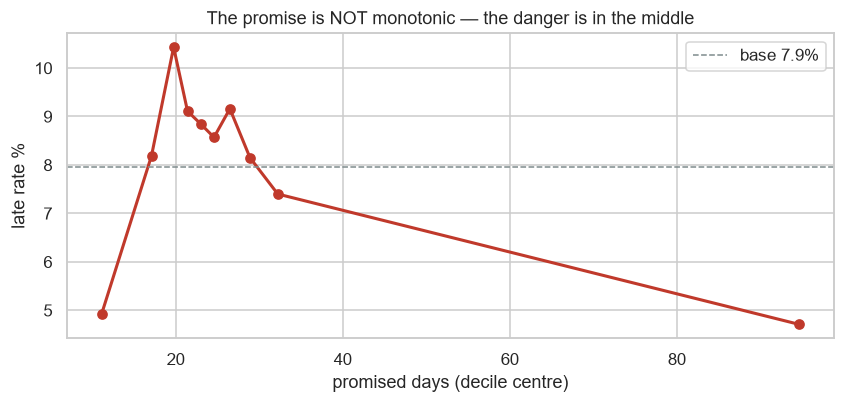

In [15]:
t_promise = lift_table(tr["promised_days"]).reset_index()
centers = [iv.mid for iv in t_promise["bin"]]

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(centers, t_promise["late %"], marker="o", color="#c0392b", linewidth=2)
ax.axhline(100*BASE, color="#7f8c8d", linestyle="--", linewidth=1,
           label=f"base {100*BASE:.1f}%")
ax.set_xlabel("promised days (decile centre)")
ax.set_ylabel("late rate %")
ax.set_title("The promise is NOT monotonic — the danger is in the middle")
ax.legend()
save_fig("03_promised_days_curve")
plt.show()

The relationship is an inverted U: short promises (<= 15 days) 4.9% late, the middle (19-21 days)
10.4%, long ones (> 34 days) 4.7%. Both ends are safe and the middle is dangerous - short promises
go to nearby customers, long ones carry a large buffer, and the middle is ambitious relative to the
distance.

A linear model reads that as a zero slope and drops the column, which argues for trees. If a linear
model is used, `promised_days` has to be binned first. And the raw number is not
the quantity of interest anyway - the promise relative to the difficulty of the shipment is, which
is section 7.

## 6. Geography

Great-circle distance between the customer and the main seller. Computed here for analysis; it
becomes a feature in notebook 5.

In [16]:
EARTH_RADIUS_KM = 6371.0

def haversine_km(lat1, lon1, lat2, lon2):
    '''Distance on the surface of a sphere between two points given in degrees.'''
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = (np.sin((lat2 - lat1)/2)**2
         + np.cos(lat1)*np.cos(lat2)*np.sin((lon2 - lon1)/2)**2)
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))

tr["distance_km"] = haversine_km(tr["customer_lat"], tr["customer_lng"],
                                 tr["seller_lat"],   tr["seller_lng"])

print(f"AUC of distance_km alone: {auc_of(tr['distance_km']):.3f}")
print(f"median: {tr['distance_km'].median():.0f} km   |   max: {tr['distance_km'].max():.0f} km")
print(f"orders longer than the width of Brazil (~4300 km): {(tr['distance_km'] > 4500).sum()}")

AUC of distance_km alone: 0.589
median: 452 km   |   max: 8033 km
orders longer than the width of Brazil (~4300 km): 3


In [17]:
lift_table(tr["distance_km"])

,orders,late %,lift
bin,,,
"(-0.001, 41.007]",6399,3.69,0.46
"(41.007, 136.407]",6399,4.52,0.57
"(136.407, 294.994]",6399,6.08,0.76
"(294.994, 356.83]",6400,8.97,1.13
"(356.83, 451.6]",6398,8.05,1.01
"(451.6, 546.654]",6399,8.05,1.01
"(546.654, 712.531]",6399,9.70,1.22
"(712.531, 889.301]",6399,8.17,1.03
"(889.301, 1469.182]",6399,9.33,1.17


-> saved: figures/04_distance_deciles.png


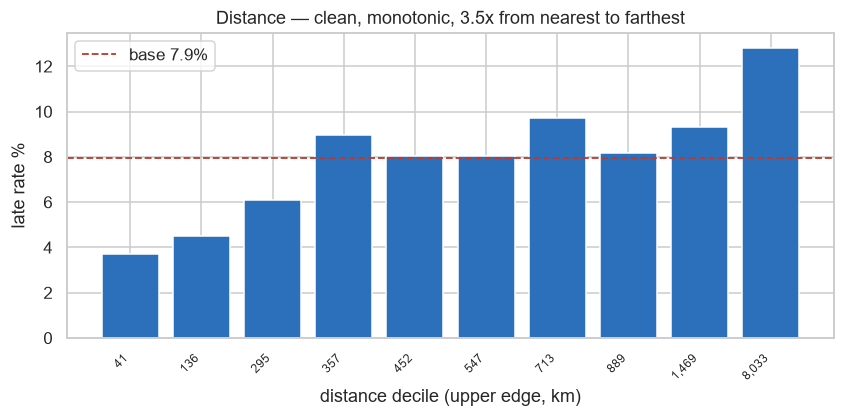

In [18]:
t_dist = lift_table(tr["distance_km"]).reset_index()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(range(len(t_dist)), t_dist["late %"], color="#2c6fbb")
ax.axhline(100*BASE, color="#c0392b", linestyle="--", linewidth=1.2,
           label=f"base {100*BASE:.1f}%")
ax.set_xticks(range(len(t_dist)))
ax.set_xticklabels([f"{iv.right:,.0f}" for iv in t_dist["bin"]], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("distance decile (upper edge, km)")
ax.set_ylabel("late rate %")
ax.set_title("Distance — clean, monotonic, 3.5x from nearest to farthest")
ax.legend()
save_fig("04_distance_deciles")
plt.show()

In [19]:
tr["same_state"] = tr["customer_state"] == tr["main_seller_state"]

same = (tr.groupby("same_state")
          .agg(orders=("is_late", "size"), late_rate=("is_late", "mean")))
same["late %"] = (100*same["late_rate"]).round(2)
same.drop(columns="late_rate")

,orders,late %
same_state,,
False,42540,9.66
True,21780,4.61


-> saved: figures/05_late_rate_by_state.png


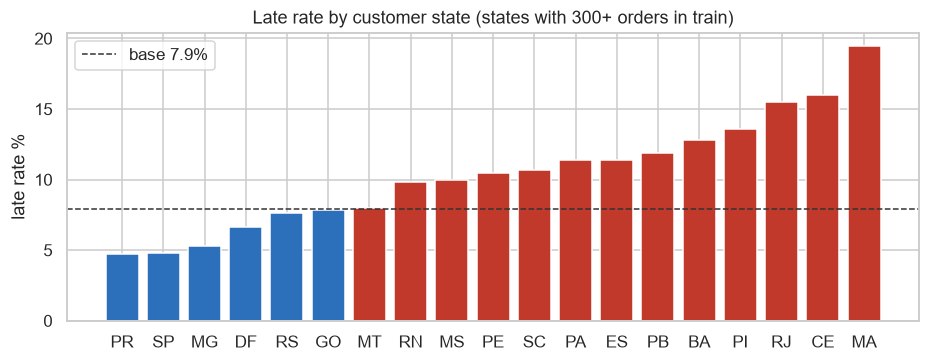

best state  : PR  (4.72%)
worst state : MA  (19.43%)


In [20]:
by_state = (tr.groupby("customer_state")
              .agg(orders=("is_late", "size"), late_rate=("is_late", "mean")))
by_state = by_state[by_state["orders"] >= 300].sort_values("late_rate")

fig, ax = plt.subplots(figsize=(10, 3.4))
colors = ["#2c6fbb" if v < BASE else "#c0392b" for v in by_state["late_rate"]]
ax.bar(by_state.index, 100*by_state["late_rate"], color=colors)
ax.axhline(100*BASE, color="#333", linestyle="--", linewidth=1, label=f"base {100*BASE:.1f}%")
ax.set_ylabel("late rate %")
ax.set_title("Late rate by customer state (states with 300+ orders in train)")
ax.legend()
save_fig("05_late_rate_by_state")
plt.show()

print(f"best state  : {by_state.index[0]}  ({100*by_state['late_rate'].iloc[0]:.2f}%)")
print(f"worst state : {by_state.index[-1]}  ({100*by_state['late_rate'].iloc[-1]:.2f}%)")

Geography is the strongest of the raw columns.

- Distance is clean and monotonic, 3.7% in the nearest decile to 12.8% in the farthest, AUC 0.589.
- Same state: 4.6% against 9.7%, and free to compute.
- Customer state: 4.8% (SP) to 19.4% (MA).

All three go in the feature list, and customer state suits target encoding as long as it is fitted
on train and saved as an object - notebook 5.

Three orders have a distance greater than the width of Brazil: corrupt coordinates that survived
the median. Negligible, but recorded.

## 7. Promise adequacy

The raw promise carries nothing and distance carries a lot, which raises the question of whether the
company already knows the distance when it sets the promise.

In [21]:
corr_promise_distance = tr[["promised_days", "distance_km"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman correlation between the promise and the distance: {corr_promise_distance:.2f}")

Spearman correlation between the promise and the distance: 0.65


0.65, so it does. The promise is stretched as distance grows, which is why the raw promise looks
signal-free - the two effects cancel.

The quantity that matters is therefore days promised per hundred kilometres: whether the promise is
generous or ambitious for the shipment it covers.

In [22]:
valid = tr["distance_km"].notna() & (tr["distance_km"] > 0)
tr.loc[valid, "promise_per_100km"] = (tr.loc[valid, "promised_days"]
                                      / (tr.loc[valid, "distance_km"] / 100))

auc = auc_of(tr["promise_per_100km"])
print(f"AUC of promise_per_100km: {auc:.3f}   ->  in the reversed direction: {1-auc:.3f}")
print(f"for comparison - distance alone: {auc_of(tr['distance_km']):.3f}")
print(f"                 promise alone : {auc_of(tr['promised_days']):.3f}")

AUC of promise_per_100km: 0.388   ->  in the reversed direction: 0.612
for comparison - distance alone: 0.589
                 promise alone : 0.487


In [23]:
lift_table(tr["promise_per_100km"])

,orders,late %,lift
bin,,,
"(0.388, 2.045]",6398,14.85,1.87
"(2.045, 2.95]",6398,9.42,1.19
"(2.95, 3.652]",6397,9.27,1.17
"(3.652, 4.455]",6398,8.28,1.04
"(4.455, 5.401]",6398,8.97,1.13
"(5.401, 6.502]",6397,8.52,1.07
"(6.502, 8.364]",6398,6.75,0.85
"(8.364, 14.222]",6397,5.64,0.71
"(14.222, 39.93]",6398,4.33,0.54


-> saved: figures/06_promise_adequacy.png


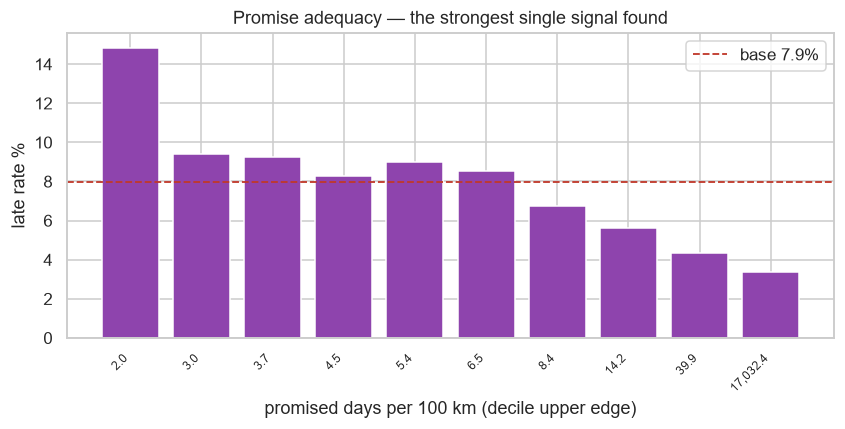

In [24]:
t_adequacy = lift_table(tr["promise_per_100km"]).reset_index()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(range(len(t_adequacy)), t_adequacy["late %"], color="#8e44ad")
ax.axhline(100*BASE, color="#c0392b", linestyle="--", linewidth=1.2,
           label=f"base {100*BASE:.1f}%")
ax.set_xticks(range(len(t_adequacy)))
ax.set_xticklabels([f"{iv.right:,.1f}" for iv in t_adequacy["bin"]], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("promised days per 100 km (decile upper edge)")
ax.set_ylabel("late rate %")
ax.set_title("Promise adequacy — the strongest single signal found")
ax.legend()
save_fig("06_promise_adequacy")
plt.show()

`promise_per_100km` reaches AUC 0.612 reversed, ahead of distance (0.589), freight (0.588) and the
raw promise (0.487). The most ambitious decile (<= 2 days/100km) is 14.9% late, the most generous
(> 40 days/100km) 3.4% - over four times.

The column existed nowhere in the data; it came out of relating two others. It goes in the feature
list, with `distance_km` and `promised_days` kept separately in case the model finds other
combinations.

## 8. Time

In [25]:
tr["dow"]   = tr["order_purchase_timestamp"].dt.dayofweek
tr["hour"]  = tr["order_purchase_timestamp"].dt.hour
tr["month"] = tr["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = (tr.groupby("dow").agg(orders=("is_late", "size"), late_rate=("is_late", "mean")))
by_dow.index = dow_names
by_dow["late %"] = (100*by_dow["late_rate"]).round(2)
by_dow.drop(columns="late_rate")

,orders,late %
Mon,10210,8.55
Tue,10290,8.03
Wed,9825,7.66
Thu,9491,7.45
Fri,9506,8.41
Sat,7287,8.04
Sun,7711,7.38


-> saved: figures/07_time_effects.png


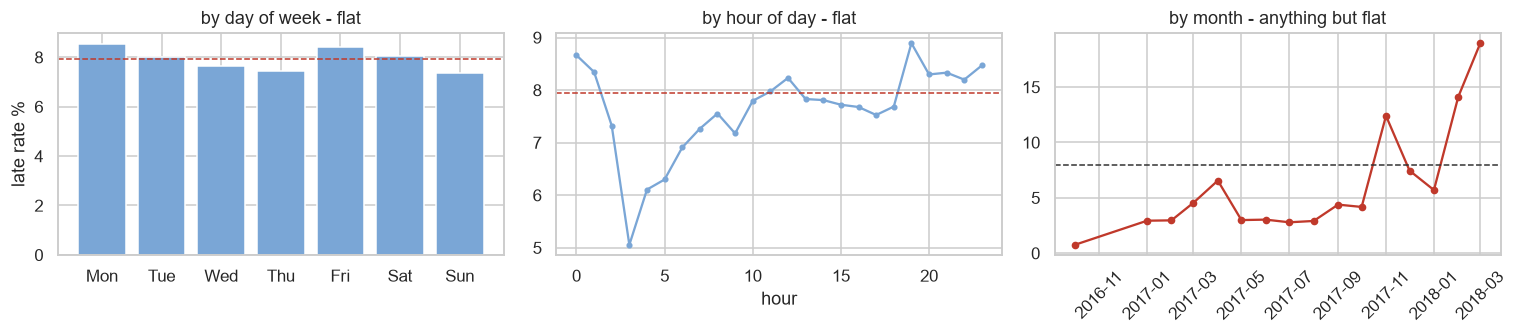

day-of-week range : 7.38% -> 8.55%
month range       : 0.75% -> 18.96%


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))

axes[0].bar(dow_names, 100*by_dow["late_rate"], color="#7aa6d6")
axes[0].axhline(100*BASE, color="#c0392b", linestyle="--", linewidth=1)
axes[0].set_title("by day of week - flat"); axes[0].set_ylabel("late rate %")

by_hour = tr.groupby("hour")["is_late"].mean()
axes[1].plot(by_hour.index, 100*by_hour, marker="o", markersize=3, color="#7aa6d6")
axes[1].axhline(100*BASE, color="#c0392b", linestyle="--", linewidth=1)
axes[1].set_title("by hour of day - flat"); axes[1].set_xlabel("hour")

by_month = tr.groupby("month").agg(n=("is_late", "size"), r=("is_late", "mean"))
by_month = by_month[by_month["n"] >= 100]
axes[2].plot(by_month.index, 100*by_month["r"], marker="o", markersize=4, color="#c0392b")
axes[2].axhline(100*BASE, color="#333", linestyle="--", linewidth=1)
axes[2].set_title("by month - anything but flat")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
save_fig("07_time_effects")
plt.show()

print(f"day-of-week range : {100*by_dow['late_rate'].min():.2f}% -> {100*by_dow['late_rate'].max():.2f}%")
print(f"month range       : {100*by_month['r'].min():.2f}% -> {100*by_month['r'].max():.2f}%")

Day of week runs 7.4% to 8.6% and the hour is flat, so neither carries much. The month runs 2.8%
to 19%, which is a large signal.

But it is `2018-03` specifically rather than March in general, and a model that learns "March 2018
was bad" has nothing to say about a future month - the reason for the chronological split.

So neither month nor year goes in. A repeatable seasonal marker could - month of year as a cycle,
a Black Friday flag - but those stay secondary candidates.

## 9. Correlations

Looking for columns that say the same thing; feeding in all of them adds dimensions without adding
information.

-> saved: figures/08_correlations.png


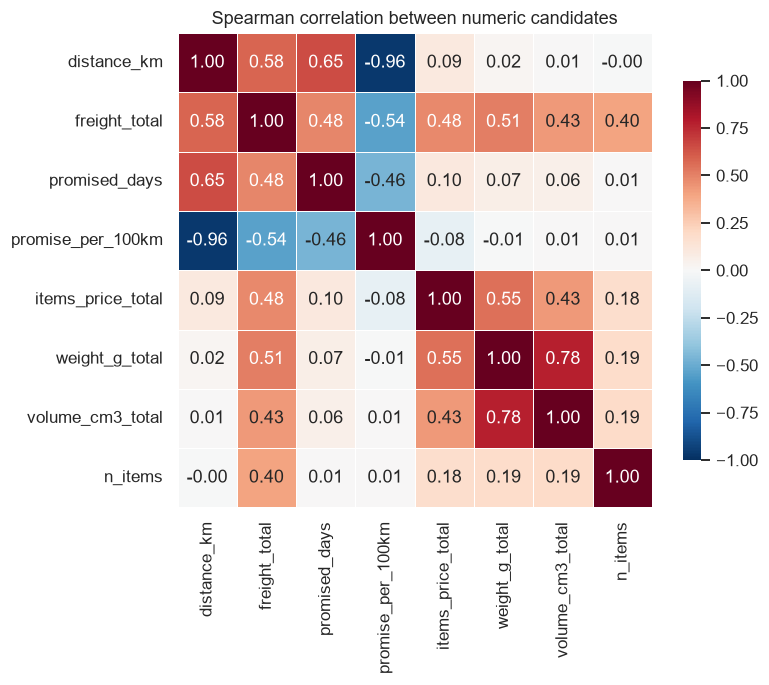

In [27]:
CORR_COLS = ["distance_km", "freight_total", "promised_days", "promise_per_100km",
             "items_price_total", "weight_g_total", "volume_cm3_total", "n_items"]

corr = tr[CORR_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.2, 5.6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, ax=ax,
            cbar_kws={"shrink": .8})
ax.set_title("Spearman correlation between numeric candidates")
save_fig("08_correlations")
plt.show()

## 10. What carries no signal

Worth recording so it is not retried, and it explains where the performance ceiling comes from.

In [28]:
weak = ["items_price_total", "weight_g_total", "volume_cm3_total",
        "n_items", "n_sellers", "installments_max", "photos_avg"]

pd.DataFrame({
    "column": weak,
    "AUC alone": [round(auc_of(tr[col]), 3) for col in weak],
    "distance from 0.5": [round(abs(auc_of(tr[col]) - 0.5), 3) for col in weak],
}).set_index("column").sort_values("distance from 0.5", ascending=False)

,AUC alone,distance from 0.5
column,,
items_price_total,0.532,0.032
weight_g_total,0.517,0.017
installments_max,0.517,0.017
photos_avg,0.485,0.015
volume_cm3_total,0.512,0.012
n_items,0.490,0.010
n_sellers,0.495,0.005


Price, weight, volume, item count and instalments all land between 0.49 and 0.53, at the edge of
randomness. Lateness here is a routing problem rather than a parcel problem - what matters is where
the parcel goes and what was promised for it.

Some stay in the feature list at low weight since they cost nothing, but nothing is expected of
them.

## 11. Feature and model decisions

In [29]:
feature_plan = pd.DataFrame([
    # (feature, type, source, strength, decision)
    ("promise_per_100km",     "derived",     "promised_days / distance",    "very strong (0.612)", "yes - first priority"),
    ("distance_km",           "derived",     "haversine on coordinates",    "strong (0.589)",      "yes"),
    ("freight_total",         "raw",         "order_items",                 "strong (0.588)",      "yes"),
    ("same_state",            "derived",     "comparing the two states",    "strong (2x)",         "yes"),
    ("customer_state",        "categorical", "customers",                   "strong (4x)",         "yes - target encoding"),
    ("main_seller_state",     "categorical", "sellers",                     "moderate (2.5x)",     "yes - target encoding"),
    ("promised_days",         "raw",         "orders",                      "non-monotonic",       "yes - for trees only"),
    ("customer_geo_missing",  "indicator",   "missing coordinates",         "moderate (+3 pp)",    "yes - missingness is signal"),
    ("main_category",         "categorical", "products",                    "weak-moderate",       "yes - after grouping rare"),
    ("weight_g_total",        "raw",         "products",                    "weak (0.517)",        "yes - at low weight"),
    ("n_items / n_sellers",   "raw",         "order_items",                 "very weak",           "yes - they cost nothing"),
    ("dow / hour",            "temporal",    "purchase timestamp",          "nothing",             "optional"),
    ("volume_cm3_total",      "raw",         "products",                    "weak + collinear",    "no - 0.78 with weight"),
    ("month / year",          "temporal",    "purchase timestamp",          "strong but a trap",   "no - does not generalise"),
    ("order_reviews.*",       "-",           "order_reviews",               "-",                   "no - leakage"),
    ("order_delivered_*",     "-",           "orders",                      "-",                   "no - leakage"),
], columns=["feature", "type", "source", "strength", "decision"])

feature_plan.set_index("feature")

,type,source,strength,decision
feature,,,,
promise_per_100km,derived,promised_days / distance,very strong (0.612),yes - first priority
distance_km,derived,haversine on coordinates,strong (0.589),yes
freight_total,raw,order_items,strong (0.588),yes
same_state,derived,comparing the two states,strong (2x),yes
customer_state,categorical,customers,strong (4x),yes - target encoding
main_seller_state,categorical,sellers,moderate (2.5x),yes - target encoding
promised_days,raw,orders,non-monotonic,yes - for trees only
customer_geo_missing,indicator,missing coordinates,moderate (+3 pp),yes - missingness is signal
main_category,categorical,products,weak-moderate,yes - after grouping rare


### Model

Trees first - Gradient Boosting or Random Forest - on three measurements from this notebook: the
inverted-U `promised_days` relationship, which a linear model reads as no signal; skew up to 11.0,
which trees ignore; and the strength of `promise_per_100km`, which is evidence that the interaction
between promise and distance carries more than either column alone.

A logistic regression still gets built in notebook 6, to measure what the trees actually added.

Task 1 measured ROC-AUC 0.679. `promise_per_100km` alone reaches 0.612 and was not in that model,
so passing 0.70 looks reasonable.

## 12. Saving the findings

In [30]:
findings = f'''# EDA findings - notebook 4

Data source: `03_train.parquet` only ({len(tr):,} orders,
{tr["order_purchase_timestamp"].min():%Y-%m-%d} -> {tr["order_purchase_timestamp"].max():%Y-%m-%d}).
Base rate: {100*BASE:.2f}% late. Neither val nor test was opened.

## The strongest signals

| Feature | AUC alone | Range |
|---|---|---|
| `promise_per_100km` (derived) | {1-auc_of(tr["promise_per_100km"]):.3f} | {t_adequacy["late %"].max():.1f}% -> {t_adequacy["late %"].min():.1f}% |
| `distance_km` | {auc_of(tr["distance_km"]):.3f} | 3.7% -> 12.8% across the deciles |
| `freight_total` | {auc_of(tr["freight_total"]):.3f} | - |
| `same_state` | - | {100*tr[tr["same_state"]]["is_late"].mean():.2f}% against {100*tr[~tr["same_state"]]["is_late"].mean():.2f}% |
| `customer_state` | - | {100*by_state["late_rate"].min():.2f}% ({by_state.index[0]}) -> {100*by_state["late_rate"].max():.2f}% ({by_state.index[-1]}) |

## Main discoveries

1. **The raw promise carries no signal (AUC {auc_of(tr["promised_days"]):.3f}) because its relationship is an inverted U:**
   short promises {t_promise["late %"].iloc[0]:.1f}% and long ones {t_promise["late %"].iloc[-1]:.1f}%, with the danger in the middle ({t_promise["late %"].max():.1f}%).
   The cause: the correlation between promise and distance = {corr_promise_distance:.2f} - the company stretches the promise with distance, so the effect cancels out.
2. **`promise_per_100km` solves the puzzle** and becomes the strongest signal in the data: from {t_adequacy["late %"].max():.1f}% at the most ambitious promise down to {t_adequacy["late %"].min():.1f}% at the most generous.
3. **Missing customer coordinates are a signal, not a gap**: {int(tr["customer_lat"].isna().sum())} orders with a late rate of {100*y[tr["customer_lat"].isna()].mean():.2f}% against {100*y[tr["customer_lat"].notna()].mean():.2f}% - added as a binary indicator.
4. **Product attributes predict nothing** (price/weight/volume/item count all ~0.5):
   lateness is a route problem, not a parcel problem.
5. **The month is a strong signal but a trap** - it does not generalise forward, deliberately excluded.
6. **The time within a day or a week is completely flat** - {100*by_dow["late_rate"].min():.2f}% to {100*by_dow["late_rate"].max():.2f}%.

## The model decision

Tree models first (a non-monotonic relationship + heavy skew + real interactions),
with a logistic regression as a baseline for comparison. The target: beat the ROC-AUC = 0.679 measured in Task 1.

## Known limitations

- {int((tr["distance_km"] > 4500).sum())} orders have a distance greater than the width of Brazil - corrupt coordinates that survived the median.
- The state of SP makes up {100*tr["main_seller_state"].value_counts(normalize=True).iloc[0]:.0f}% of the sellers - state features are effectively "SP versus the rest".
- {len(rare)} rare product categories (<100 orders) cover {100*rare.sum()/len(tr):.1f}% - grouped into "rare".
'''

out = ARTIFACTS / "04_findings.md"
out.write_text(findings, encoding="utf-8")
print(f"saved: {out}")
print(f"figures: {len(list(FIGURES.glob('*.png')))} files in figures/")

saved: ..\artifacts\04_findings.md
figures: 12 files in figures/
